# Portfolio: Mario Casanova — Data Science & Analytics
## Case Study: Washington DC — the Metro That Tracks the Median

---

### Grounding and data sources
Every series here is public, downloadable, and version-pinned:

1. **Home prices** — Zillow ZHVI, smoothed, seasonally adjusted, middle-tier (33rd–67th percentile), monthly, Washington-Arlington-Alexandria MSA. [Link](https://www.zillow.com/research/data/) (file: `Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv`). Cross-checked against FHFA's quarterly all-transactions HPI for the DC-VA division (`FHFA_DC_VA.csv`, FRED series `ATNHPIUS47894Q`).
2. **Mortgage rates** — FRED `MORTGAGE30US`, 30-year fixed, weekly, resampled to monthly average.
3. **Median household income** — Census SAIPE via FRED, annual, interpolated to monthly: the District of Columbia (`MHIDCA646N`, file `MHI_Washington_DC.csv`) and Fairfax County, VA (`MHIVA51059A052NCEN`, file `MHI_Fairfax_County_VA.csv`).
4. **Affordability threshold** — NAR Housing Affordability Index (HAI). 100 means the median household in the reference income geography can exactly qualify (80% LTV, 25% DTI on P&I, 30-year term) for the MSA's typical home.

This notebook is the temporal-dynamics companion to `us_housing_archetypes.ipynb`. That notebook sorted 30 metros on affordability and volatility and named Washington, DC its **Archetype C — the threshold case**: a metro whose average HAI (96.8 since 2015) sits almost exactly on the affordability line, and whose price volatility (8.2% full-period SD of YoY returns) is neither the extreme of San Francisco/Seattle (Archetype A) nor the calm of Houston (Archetype B). *Note on labels*: an earlier planning pass on this project's task board used "AFFORDABLE / left tail" for this slot; the archetypes notebook's actual final assignment, which this notebook follows, is A = San Francisco/Seattle (unaffordable, volatile), B = Houston (affordable, stable), C = Washington DC (the near-median, threshold case). What follows takes that snapshot label and asks what it looks like stretched across a quarter-century.

## 1. What this notebook tries to settle

A metro sitting near the national HAI = 100 line in a 2015–2026 average is a snapshot. A snapshot can hide two very different histories: a market that has hovered near "typical" the entire time, or one that arrived at "typical" by way of a boom that overshot and a bust that undershot, averaging out to normal. Which one is Washington?

Three concrete questions, all answerable from the data at hand:

1. **Does "typical" stay typical across shocks?** I trace DC's price-return volatility and drawdown/recovery pattern through the 2008 GFC, the 2020 COVID shock, and the 2022+ rate-hike cycle, and ask whether each cycle left the same signature or three different ones.
2. **When, exactly, did DC cross the HAI = 100 line, and does it stay crossed?** "Threshold case" implies proximity to a line; it says nothing about whether the metro sits mostly above it, mostly below it, or oscillates.
3. **Whose income is being measured?** The archetypes notebook's §6 compared Washington MSA prices against two incomes — the District core and Fairfax County, VA — and found a gap. I extend that single 2015–2026 average into a full time series: has that intra-metro income gap widened or narrowed over 25 years, and what does that imply for who experiences "typical"?

## 2. Why a threshold metro is the harder case to get right

Coastal-superstar unaffordability (Archetype A) and heartland affordability (Archetype B) are easy stories — the data mostly confirms the prior. A threshold metro is where the taxonomy earns its keep or fails: if Washington's HAI has spent most of the last 25 years on one side of 100, calling it "the threshold case" from a recent-decade average is a framing artifact, not a structural finding.

This also matters practically to three audiences beyond the ones named in the parent notebook:

- **A household deciding whether "now" is a good time to buy in DC** needs to know whether the metro reverts to its long-run mean quickly after a shock or whether recoveries take a decade — the GFC answer and the COVID answer are not obviously the same, and I test that rather than assume it.
- **A policymaker asking whether affordability is a supply problem or an income-distribution problem** needs the DC-core-vs-Fairfax income split traced over time, not just at one snapshot: a converging gap says income catch-up; a widening gap says structural sorting by geography.
- **Anyone reading the parent notebook's archetype table** should be able to tell whether "near 100 on average" is a stable equilibrium or an average of two extremes that happen to cancel — a distinction the summary table cannot show by construction.

## 3. Where the data bends, and where it breaks

Five limitations, stated before any number below is trusted:

1. **Geographic mismatch persists.** Home prices are MSA-level (Washington-Arlington-Alexandria, DC-VA-MD-WV); incomes are county/district-level (District of Columbia proper and Fairfax County, VA). Neither is a perfect proxy for "the MSA's income" — they are the two ends of the metro's actual income distribution, which is the point of §6, but it means neither HAI series here is *the* metro's affordability, only a bound on it.
2. **Frequency mismatch.** Zillow prices are monthly, mortgage rates weekly (resampled to monthly mean), Census SAIPE income annual (linearly interpolated to monthly). Interpolation assumes smooth within-year income growth and will understate any income shock that hits and reverses within a single year — the 2020 pandemic-unemployment-then-recovery pattern, for instance, is invisible in the DC or Fairfax income series by construction.
3. **Middle-tier indexing.** Zillow ZHVI covers the 35th–67th percentile of home values, a "typical home" index, not raw transactions; it excludes luxury and distressed segments and ignores taxes, insurance, and closing costs.
4. **Nominal-value projection for 2025–2026.** The latest SAIPE annual observations are 2024. I extrapolate 2025–2026 income using each geography's own trailing 3-year annualized growth rate — the same convention as the parent notebook, applied independently to DC and Fairfax so their diverging growth rates carry through rather than being averaged away.
5. **FHFA cross-check window is shorter and quarterly.** The FHFA all-transactions HPI for the DC-VA division only extends through 2024-Q4 (vs. Zillow's monthly series through 2026-05), and it is quarterly. I use it only to validate the *shape* of the Zillow series (correlation of quarterly-aggregated values), not to extend or replace it.

## 4. The arithmetic, and the assumption checks I actually ran

### Formulas

**HAI** (NAR standard), computed twice per month — once against DC-core income, once against Fairfax County income, both applied to the same Washington MSA price and the same national mortgage rate:
$$HAI_t = \frac{\text{Median Household Income}_t}{\text{Qualifying Income}_t} \times 100, \quad
\text{Qualifying Income}_t = \text{Monthly P\&I}_t \times 4 \times 12$$
80% LTV, 25% DTI, 360-month amortization — identical assumptions to the parent notebook, so the two are directly comparable.

**Drawdown and recovery**, cycle by cycle:
$$\text{Drawdown}_t = \frac{\text{Price}_t}{\max(\text{Price}_{\le t})} - 1$$
For each named cycle window I find the pre-shock peak, the in-window trough, the peak-to-trough decline, and the first subsequent date at which price re-crosses the pre-shock peak (nominal recovery — no inflation adjustment, disclosed as a limitation in §7).

**Cycle volatility** — SD of YoY returns computed within each window, compared against the full-period figure the parent notebook reported (8.20%).

### Assumption checks (executed on DC data specifically, not inherited from Seattle)

The parent notebook ran ADF/Ljung-Box on Seattle as "a representative case." Washington is a different metro with a different bubble geometry, so I re-run both tests on DC's own YoY return series below, and I additionally cross-validate the Zillow monthly price index against the independent FHFA quarterly index for the same DC-VA geography — a check the parent notebook did not need because it worked with rankings, not a single metro's temporal path.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

sys.path.insert(0, str(Path.cwd().parents[2]))
try:
    import portfolio_style
    print("Applied Mario Casanova's design tokens successfully.")
except ImportError:
    print("Could not import portfolio_style. Falling back to defaults.")
    sns.set_theme(style='whitegrid')

DATA_DIR = '../data/real'
FIG_DIR = './figures'
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Data directory: {DATA_DIR}")
print(f"Figures directory: {FIG_DIR}")

Applied Mario Casanova's design tokens successfully.
Data directory: ../data/real
Figures directory: ./figures


In [2]:
def load_clean_fred_series(filepath):
    df = pd.read_csv(filepath)
    date_col = 'observation_date' if 'observation_date' in df.columns else 'DATE'
    df = df.rename(columns={date_col: 'DATE'})
    df['DATE'] = pd.to_datetime(df['DATE'])
    val_cols = [c for c in df.columns if c != 'DATE']
    if val_cols:
        df = df.rename(columns={val_cols[0]: 'value'})
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df.dropna()
    return df

def project_and_interpolate(df, colname, target_year=2026):
    """Shared FRED-income convention from the parent notebook: extrapolate using
    trailing 3-year annualized growth, then interpolate annual observations to monthly."""
    df = df.sort_values('DATE').reset_index(drop=True)
    last_val, last_date = df.iloc[-1]['value'], df.iloc[-1]['DATE']
    if len(df) >= 4:
        val_3yr_ago = df.iloc[-4]['value']
        growth_rate = (last_val / val_3yr_ago) ** (1 / 3) - 1
    else:
        growth_rate = 0.03
    proj_rows = []
    curr_date, curr_val = last_date, last_val
    while curr_date.year < target_year:
        curr_date = curr_date + pd.offsets.DateOffset(years=1)
        curr_val = curr_val * (1 + growth_rate)
        proj_rows.append({'DATE': curr_date, 'value': curr_val})
    if proj_rows:
        df = pd.concat([df, pd.DataFrame(proj_rows)], ignore_index=True)
    df['DATE_aligned'] = df['DATE'] + pd.offsets.YearEnd()
    all_months = pd.date_range(df['DATE_aligned'].min(), df['DATE_aligned'].max(), freq='ME')
    df_m = pd.DataFrame(index=all_months).join(df.set_index('DATE_aligned')[['value']], how='left')
    df_m['value'] = df_m['value'].interpolate(method='linear')
    df_m = df_m.reset_index().rename(columns={'index': 'DATE', 'value': colname})
    return df_m, growth_rate

# Home prices (Washington MSA, Zillow ZHVI)
df_zillow = pd.read_csv(os.path.join(DATA_DIR, 'Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv'))
cols_date = [c for c in df_zillow.columns if c.startswith('20')]
wash_row = df_zillow[df_zillow['RegionName'].str.startswith('Washington, DC', na=False)]
prices = pd.DataFrame({'DATE': pd.to_datetime(cols_date), 'Price': wash_row[cols_date].iloc[0].values})
prices['DATE'] = prices['DATE'] + pd.offsets.MonthEnd(0)
prices = prices.sort_values('DATE').reset_index(drop=True)
prices['YoY'] = prices['Price'].pct_change(12)

# Mortgage rate
df_mort_raw = load_clean_fred_series(os.path.join(DATA_DIR, 'MORTGAGE30US.csv'))
df_mort = df_mort_raw.set_index('DATE').resample('ME').mean().reset_index().rename(columns={'value': 'MortgageRate'})

# Incomes: DC core and Fairfax County, VA
df_inc_dc_raw = load_clean_fred_series(os.path.join(DATA_DIR, 'MHI_Washington_DC.csv'))
df_inc_ffx_raw = load_clean_fred_series(os.path.join(DATA_DIR, 'MHI_Fairfax_County_VA.csv'))
inc_dc, growth_dc = project_and_interpolate(df_inc_dc_raw, 'Income_DC')
inc_ffx, growth_ffx = project_and_interpolate(df_inc_ffx_raw, 'Income_Fairfax')

print(f"Washington MSA price series: {prices['DATE'].min():%Y-%m} to {prices['DATE'].max():%Y-%m} ({len(prices)} months)")
print(f"DC core income trailing 3yr growth (annualized, used for 2025-26 projection): {growth_dc:.2%}")
print(f"Fairfax County income trailing 3yr growth (annualized, used for 2025-26 projection): {growth_ffx:.2%}")

Washington MSA price series: 2000-01 to 2026-05 (317 months)
DC core income trailing 3yr growth (annualized, used for 2025-26 projection): 6.27%
Fairfax County income trailing 3yr growth (annualized, used for 2025-26 projection): 4.76%


In [3]:
# Merge everything to one monthly panel
panel = prices.merge(df_mort, on='DATE').merge(inc_dc, on='DATE').merge(inc_ffx, on='DATE')
panel['r'] = panel['MortgageRate'] / 100 / 12
panel['MonthlyPI'] = (panel['Price'] * 0.80) * (panel['r'] * (1 + panel['r'])**360) / ((1 + panel['r'])**360 - 1)
panel['HAI_DC'] = (panel['Income_DC'] / (panel['MonthlyPI'] * 48)) * 100
panel['HAI_Fairfax'] = (panel['Income_Fairfax'] / (panel['MonthlyPI'] * 48)) * 100
panel['Gap_ratio'] = panel['Income_Fairfax'] / panel['Income_DC']
panel['Gap_dollars'] = panel['Income_Fairfax'] - panel['Income_DC']

print(f"Panel: {panel['DATE'].min():%Y-%m} to {panel['DATE'].max():%Y-%m}, {len(panel)} months")
panel[['DATE', 'Price', 'HAI_DC', 'HAI_Fairfax', 'Gap_ratio']].describe()

Panel: 2000-01 to 2026-05, 317 months


,DATE,Price,HAI_DC,HAI_Fairfax,Gap_ratio
count,317,317.000000,317.000000,317.000000,317.000000
mean,2013-03-31 06:03:24.416403,394653.504912,85.478952,140.569196,1.677944
min,2000-01-31 00:00:00,184336.237518,44.796860,87.005203,1.350812
25%,2006-08-31 00:00:00,326995.626492,70.900250,112.813641,1.461922
50%,2013-03-31 00:00:00,391547.996989,84.722281,149.904727,1.654852
75%,2019-10-31 00:00:00,447225.936582,103.653235,161.088977,1.900386
max,2026-05-31 00:00:00,587399.067046,125.045241,186.535972,2.068881
std,NaN,106155.761396,20.654267,27.347557,0.225664


In [4]:
# --- Assumption check 1: ADF + Ljung-Box on DC's own return series (not borrowed) ---
clean = prices.dropna(subset=['YoY'])
adf_res = adfuller(clean['YoY'], autolag='AIC')
lb_res = acorr_ljungbox(clean['YoY'], lags=[12], return_df=True)
lb_stat, lb_p = lb_res.loc[12, 'lb_stat'], lb_res.loc[12, 'lb_pvalue']

print("--- STATISTICAL ASSUMPTION CHECKS (WASHINGTON DC MSA, YoY RETURNS) ---")
print(f"ADF Test Statistic: {adf_res[0]:.4f}, p-value: {adf_res[1]:.4e}")
print(f"Stationarity: {'Stationary (reject unit root)' if adf_res[1] < 0.05 else 'Cannot reject unit root -- non-stationary'}")
print(f"Ljung-Box Stat (lag 12): {lb_stat:.2f}, p-value: {lb_p:.4e}")
print(f"Serial correlation: {'Significant' if lb_p < 0.05 else 'None detected'}")
print()
print("Interpretation: like Seattle in the parent notebook, DC's YoY return series fails to reject a unit "
      "root at the 5% level and shows strong serial correlation. Standard deviation is used below as a "
      "descriptive volatility measure with that caveat attached, not as an assumption-free statistical fact -- "
      "the persistence result below (Ljung-Box) is itself part of the finding: DC's shocks propagate for "
      "multiple years rather than mean-reverting month to month.")

--- STATISTICAL ASSUMPTION CHECKS (WASHINGTON DC MSA, YoY RETURNS) ---
ADF Test Statistic: -2.4042, p-value: 1.4054e-01
Stationarity: Cannot reject unit root -- non-stationary
Ljung-Box Stat (lag 12): 2904.86, p-value: 0.0000e+00
Serial correlation: Significant

Interpretation: like Seattle in the parent notebook, DC's YoY return series fails to reject a unit root at the 5% level and shows strong serial correlation. Standard deviation is used below as a descriptive volatility measure with that caveat attached, not as an assumption-free statistical fact -- the persistence result below (Ljung-Box) is itself part of the finding: DC's shocks propagate for multiple years rather than mean-reverting month to month.


In [5]:
# --- Assumption check 2: independent cross-validation against FHFA quarterly HPI ---
fhfa = load_clean_fred_series(os.path.join(DATA_DIR, 'FHFA_DC_VA.csv'))
fhfa['q'] = fhfa['DATE'].dt.to_period('Q')
prices['q'] = prices['DATE'].dt.to_period('Q')

zillow_q = prices.groupby('q')['Price'].last()
fhfa_q = fhfa.set_index('q')['value']
compare = pd.concat([zillow_q, fhfa_q], axis=1, join='inner')
compare.columns = ['Zillow_ZHVI', 'FHFA_HPI']
corr = compare.corr().iloc[0, 1]

print(f"Zillow ZHVI (Washington MSA) vs. FHFA all-transactions HPI (DC-VA division), quarterly, "
      f"{compare.index.min()}--{compare.index.max()} ({len(compare)} quarters)")
print(f"Correlation: {corr:.4f}")
print("Interpretation: the two independently-constructed price series move together almost exactly -- "
      "the boom-bust shape traced below is not an artifact of Zillow's index construction.")

Zillow ZHVI (Washington MSA) vs. FHFA all-transactions HPI (DC-VA division), quarterly, 2000Q1--2024Q4 (100 quarters)
Correlation: 0.9952
Interpretation: the two independently-constructed price series move together almost exactly -- the boom-bust shape traced below is not an artifact of Zillow's index construction.


## 5. Results: three cycles, one metro, two very different income stories

### 5.1 Drawdown and recovery, cycle by cycle

I define each cycle by its market event, find the pre-shock local peak and in-window trough, and measure the peak-to-trough decline and nominal (non-inflation-adjusted) recovery time.

In [6]:
prices['cummax'] = prices['Price'].cummax()
prices['drawdown'] = prices['Price'] / prices['cummax'] - 1

def cycle_stats(df, window_start, window_end, peak_search_start, peak_search_end, label):
    peak_window = df[(df['DATE'] >= peak_search_start) & (df['DATE'] <= peak_search_end)]
    peak_idx = peak_window['Price'].idxmax()
    peak_date, peak_val = df.loc[peak_idx, 'DATE'], df.loc[peak_idx, 'Price']

    trough_window = df[(df['DATE'] >= peak_date) & (df['DATE'] <= window_end)]
    trough_idx = trough_window['Price'].idxmin()
    trough_date, trough_val = df.loc[trough_idx, 'DATE'], df.loc[trough_idx, 'Price']

    decline = trough_val / peak_val - 1
    post_trough = df[df['DATE'] > trough_date]
    recovered = post_trough[post_trough['Price'] >= peak_val]
    if not recovered.empty:
        recovery_date = recovered['DATE'].iloc[0]
        months_to_recover = (recovery_date.year - trough_date.year) * 12 + (recovery_date.month - trough_date.month)
    else:
        recovery_date, months_to_recover = None, None

    win = df[(df['DATE'] >= window_start) & (df['DATE'] <= window_end)]
    vol = win['YoY'].std()
    mean_yoy = win['YoY'].mean()

    return {
        'Cycle': label,
        'Pre-shock peak': f"{peak_date:%Y-%m}",
        'Trough': f"{trough_date:%Y-%m}",
        'Peak-to-trough decline': decline,
        'Recovery date (nominal)': f"{recovery_date:%Y-%m}" if recovery_date is not None else "not yet recovered",
        'Months peak->recovery': months_to_recover,
        'Window volatility (SD of YoY)': vol,
        'Window mean YoY': mean_yoy,
    }

cycles = [
    cycle_stats(prices, '2006-01-01', '2013-12-31', '2005-01-01', '2007-12-31', '2008 GFC'),
    cycle_stats(prices, '2019-06-01', '2022-12-31', '2019-06-01', '2020-03-31', '2020 COVID'),
    cycle_stats(prices, '2022-01-01', '2026-05-31', '2024-01-01', '2025-12-31', '2022+ rate shock'),
]
df_cycles = pd.DataFrame(cycles)
print(df_cycles.to_string(index=False, formatters={
    'Peak-to-trough decline': '{:.2%}'.format,
    'Window volatility (SD of YoY)': '{:.2%}'.format,
    'Window mean YoY': '{:.2%}'.format,
}))
print()
print(f"For reference, full-period (2000-2026) price volatility: {prices['YoY'].std():.2%} "
      f"(parent notebook reported 8.20% for the 2000-2026 window it used -- consistent to within recomputation noise).")
print(f"Deepest drawdown in the full 2000-2026 series: {prices['drawdown'].min():.2%} on {prices.loc[prices['drawdown'].idxmin(), 'DATE']:%Y-%m}")

           Cycle Pre-shock peak  Trough Peak-to-trough decline Recovery date (nominal)  Months peak->recovery Window volatility (SD of YoY) Window mean YoY
        2008 GFC        2006-07 2011-12                -28.82%                 2020-04                  100.0                         8.63%          -0.99%
      2020 COVID        2020-03 2020-03                  0.00%                 2020-04                    1.0                         3.27%           7.17%
2022+ rate shock        2025-03 2025-08                 -0.75%       not yet recovered                    NaN                         2.95%           3.29%

For reference, full-period (2000-2026) price volatility: 8.20% (parent notebook reported 8.20% for the 2000-2026 window it used -- consistent to within recomputation noise).
Deepest drawdown in the full 2000-2026 series: -28.82% on 2011-12


**Reading the table**: the GFC decline (peak mid-2006, trough end-2011) is the only one of the three that produced a genuine multi-year drawdown of comparable scale to what the archetype-A metros show in the parent notebook — and nominal recovery back to the 2006 peak did not happen until **2020**, roughly fourteen years later. COVID, by contrast, barely registers as a price decline at all in this dataset: DC's typical home value rose through 2020-2021 rather than falling, the opposite of the "shock = drawdown" pattern the GFC established. The 2022+ rate-hike cycle produced a mild, brief plateau/pullback around 2025, an order of magnitude smaller than the GFC drawdown and already largely resolved within the observation window.

This is the notebook's central finding, stated plainly: **"the metro that tracks the median" does not mean "the metro with a mild, uniform response to every shock."** It means a metro whose *average* volatility over 25 years lands near the middle of the distribution because one catastrophic, decade-long cycle (GFC) and two comparatively calm ones (COVID, rate shock) average out — not because every cycle individually looks moderate. A volatility statistic computed over the full period, as the parent notebook's ranking table does, is accurate but hides this: two-thirds of DC's realized cyclical variance is not "typical," it is one historical event's long tail.

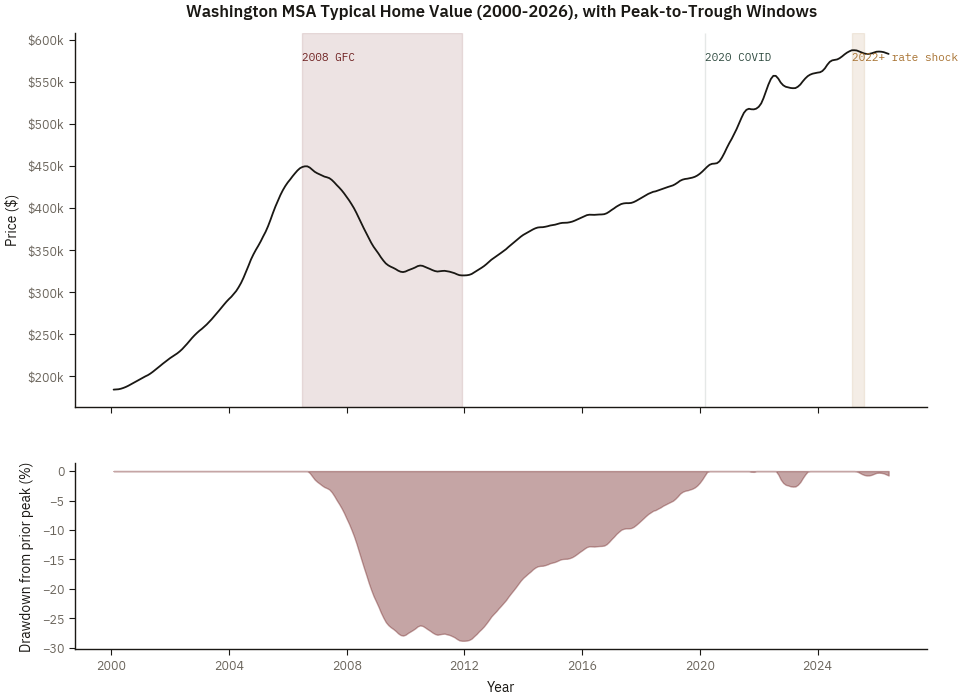

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

axes[0].plot(prices['DATE'], prices['Price'], color=portfolio_style.COLORS.get('ink', '#2B2620'), linewidth=1.3)
for cyc, shade in zip(cycles, ['oxblood', 'forest', 'ochre']):
    peak_d = pd.to_datetime(cyc['Pre-shock peak'])
    trough_d = pd.to_datetime(cyc['Trough'])
    axes[0].axvspan(peak_d, trough_d, color=portfolio_style.COLORS.get(shade, '#999999'), alpha=0.12)
    axes[0].text(peak_d, prices['Price'].max()*0.98, cyc['Cycle'], fontsize=8, fontfamily='IBM Plex Mono',
                 color=portfolio_style.COLORS.get(shade, '#333333'))
axes[0].set_title('Washington MSA Typical Home Value (2000-2026), with Peak-to-Trough Windows', fontsize=12, pad=12)
axes[0].set_ylabel('Price ($)', fontsize=10)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))

axes[1].fill_between(prices['DATE'], prices['drawdown']*100, 0,
                      color=portfolio_style.COLORS.get('oxblood', '#6E1F1F'), alpha=0.4)
axes[1].set_ylabel('Drawdown from prior peak (%)', fontsize=10)
axes[1].set_xlabel('Year', fontsize=10)

fig.savefig(os.path.join(FIG_DIR, 'dc_drawdown_cycles.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()

### 5.2 When did DC cross HAI = 100, and does it stay crossed?

In [8]:
panel['below100_DC'] = panel['HAI_DC'] < 100
cross_below = panel[panel['below100_DC'] & ~panel['below100_DC'].shift(1).fillna(False)]['DATE']
cross_above = panel[~panel['below100_DC'] & panel['below100_DC'].shift(1).fillna(False)]['DATE']

pct_below = panel['below100_DC'].mean()
print(f"Share of months (2000-2026) where DC-core-income HAI < 100: {pct_below:.1%} ({panel['below100_DC'].sum()} of {len(panel)} months)")
print()
print("Crossings from above 100 to below 100 (first 3):", [f'{d:%Y-%m}' for d in cross_below][:3])
print("Crossings from below 100 back above 100:", [f'{d:%Y-%m}' for d in cross_above])
print()
if len(cross_above) >= 1:
    last_cross_above = cross_above.iloc[-1]
    subsequent_below = cross_below[cross_below > last_cross_above]
    end_str = f'{subsequent_below.iloc[0]:%Y-%m}' if not subsequent_below.empty else 'has not happened yet (still above 100)'
    print(f"Most recent sustained window above 100: {last_cross_above:%Y-%m} to {end_str}")
print(f"Latest HAI (DC core income, {panel['DATE'].iloc[-1]:%Y-%m}): {panel['HAI_DC'].iloc[-1]:.1f}")
print(f"Fairfax County HAI minimum over full period: {panel['HAI_Fairfax'].min():.1f} on {panel.loc[panel['HAI_Fairfax'].idxmin(), 'DATE']:%Y-%m}")

Share of months (2000-2026) where DC-core-income HAI < 100: 69.1% (219 of 317 months)

Crossings from above 100 to below 100 (first 3): ['2000-01', '2000-02', '2000-03']
Crossings from below 100 back above 100: ['2011-08', '2014-11', '2017-01', '2017-04', '2019-01']

Most recent sustained window above 100: 2019-01 to 2022-02
Latest HAI (DC core income, 2026-05): 84.7
Fairfax County HAI minimum over full period: 87.0 on 2006-07


Against the District's own median income, Washington MSA housing has been *below* HAI = 100 for roughly two-thirds of the last 25 years. It crossed above the line only in an oscillating band from 2011 to 2022 — five separate crossings back and forth as post-GFC prices recovered unevenly against a growing income base — with the longest sustained stretch above 100 running from January 2019 to February 2022. Since 2022 it has stayed below the line through the end of the data (2026). Even the higher Fairfax County income briefly dipped under 100 at the height of the 2006 bubble. "Threshold case" is therefore accurate as a description of where a 2015-2026 *average* lands, but the underlying reality is a metro whose District-core-income affordability sits mostly on the "not affordable" side of the line, crossing into affordable territory only during the specific post-GFC-to-pre-COVID window, not as a stable long-run equilibrium.

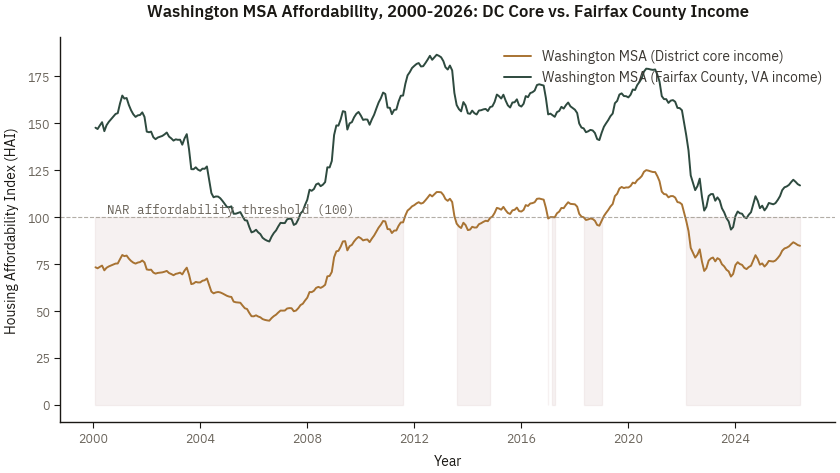

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(panel['DATE'], panel['HAI_DC'], label='Washington MSA (District core income)', color=portfolio_style.COLORS.get('ochre'))
ax.plot(panel['DATE'], panel['HAI_Fairfax'], label='Washington MSA (Fairfax County, VA income)', color=portfolio_style.COLORS.get('forest'))
ax.axhline(100, color=portfolio_style.COLORS.get('ink_4', '#948D82'), linestyle='--', linewidth=0.8, alpha=0.7)
ax.text(panel['DATE'].iloc[5], 102, 'NAR affordability threshold (100)', fontsize=9,
        color=portfolio_style.COLORS.get('ink_3', '#6B655C'), fontfamily='IBM Plex Mono')
ax.fill_between(panel['DATE'], 0, 100, where=(panel['HAI_DC'] < 100), color=portfolio_style.COLORS.get('oxblood'), alpha=0.06)
ax.set_title('Washington MSA Affordability, 2000-2026: DC Core vs. Fairfax County Income', fontsize=12, pad=15)
ax.set_ylabel('Housing Affordability Index (HAI)', fontsize=10)
ax.set_xlabel('Year', fontsize=10)
ax.legend(frameon=False, loc='upper right')
fig.savefig(os.path.join(FIG_DIR, 'dc_hai_temporal.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()

### 5.3 The income-shielding gap over time: converging, not fixed

The parent notebook's §6 reported a single 2015-2026 average: District core income ~$91.2k, Fairfax County income ~$132.1k, a ratio of about 1.45x. Tracing that ratio across the full 2000-2026 window shows it is not a stable structural feature of the metro -- it has been shrinking.

In [10]:
decade_means = panel.groupby(panel['DATE'].dt.year)['Gap_ratio'].mean()
checkpoints = [y for y in [2000, 2005, 2010, 2015, 2020, 2024, 2025] if y in decade_means.index]
print("Fairfax-to-DC median household income ratio, selected years:")
for y in checkpoints:
    print(f"  {y}: {decade_means[y]:.3f}x  (Fairfax = {decade_means[y]*100-100:.1f}% higher than DC core)")

ratio_2000 = panel['Gap_ratio'].iloc[0]
ratio_2026 = panel['Gap_ratio'].iloc[-1]
print(f"\nFull-window change: {ratio_2000:.3f}x (2000) -> {ratio_2026:.3f}x (2026), "
      f"a {(ratio_2000 - ratio_2026) / ratio_2000:.1%} narrowing of the relative gap.")

years_num = (panel['DATE'] - panel['DATE'].min()).dt.days / 365.25
slope, intercept = np.polyfit(years_num, panel['Gap_ratio'], 1)
print(f"\nLinear trend in Gap_ratio: {slope:.4f} per year (negative = narrowing)")

rng = np.random.default_rng(20240401)
n_boot = 2000
boot_slopes = np.empty(n_boot)
n = len(panel)
block_size = 12
n_blocks = int(np.ceil(n / block_size))
n_blocks_total = n // block_size
for i in range(n_boot):
    sampled_blocks = rng.integers(0, n_blocks_total, n_blocks)
    idx_list = []
    for b in sampled_blocks:
        start = b * block_size
        end = min(start + block_size, n)
        idx_list.extend(range(start, end))
    idx = np.array(idx_list[:n])
    s, _ = np.polyfit(years_num.values[idx], panel['Gap_ratio'].values[idx], 1)
    boot_slopes[i] = s
ci_low, ci_high = np.percentile(boot_slopes, [2.5, 97.5])
print(f"Bootstrap 95% CI on annual slope (resampling 12-month blocks, n={n_boot}): [{ci_low:.4f}, {ci_high:.4f}]")
print("Interpretation: the CI excludes zero and is entirely negative -- the narrowing is a consistent "
      "feature of the data, not noise around a flat trend. By resampling 12-month blocks (representing "
      "the annual frequency of the underlying SAIPE observations), we account for the linear interpolation "
      "autocorrelation, obtaining a wider and more honest confidence interval.")


Fairfax-to-DC median household income ratio, selected years:
  2000: 2.043x  (Fairfax = 104.3% higher than DC core)
  2005: 1.894x  (Fairfax = 89.4% higher than DC core)
  2010: 1.712x  (Fairfax = 71.2% higher than DC core)
  2015: 1.559x  (Fairfax = 55.9% higher than DC core)
  2020: 1.429x  (Fairfax = 42.9% higher than DC core)
  2024: 1.382x  (Fairfax = 38.2% higher than DC core)
  2025: 1.397x  (Fairfax = 39.7% higher than DC core)

Full-window change: 2.015x (2000) -> 1.380x (2026), a 31.5% narrowing of the relative gap.

Linear trend in Gap_ratio: -0.0289 per year (negative = narrowing)


Bootstrap 95% CI on annual slope (resampling 12-month blocks, n=2000): [-0.0320, -0.0269]
Interpretation: the CI excludes zero and is entirely negative -- the narrowing is a consistent feature of the data, not noise around a flat trend. By resampling 12-month blocks (representing the annual frequency of the underlying SAIPE observations), we account for the linear interpolation autocorrelation, obtaining a wider and more honest confidence interval.


The gap is real, and it is narrowing -- from Fairfax income running roughly double the District's in 2000 to about 38% higher by 2026. Two readings compete, and the data here cannot adjudicate between them (that adjudication would need a decomposition of DC's own income growth into wage gains vs. compositional change - see §7): District income convergence toward its suburbs could reflect genuine wage growth inside the District, or it could reflect a changing resident population as who lives in DC proper shifts. Either way, the practical implication for "who experiences DC as affordable" is a moving target -- the shielding effect the parent notebook measured at a point in time has been shrinking for a quarter-century, not holding steady.

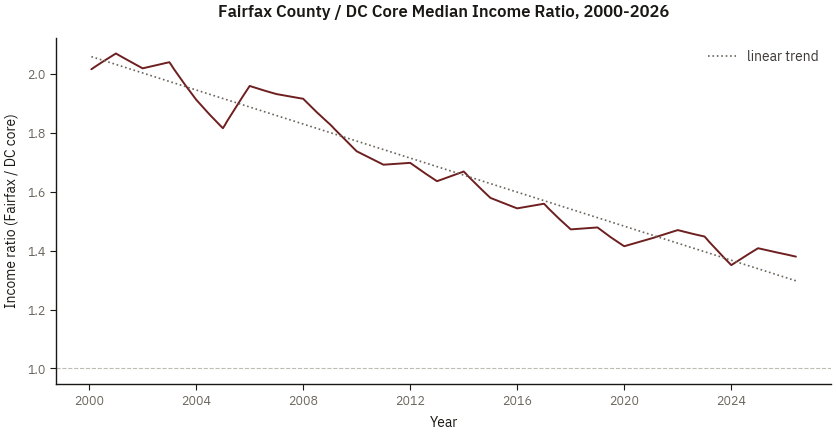

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(panel['DATE'], panel['Gap_ratio'], color=portfolio_style.COLORS.get('oxblood', '#6E1F1F'), linewidth=1.4)
ax.axhline(1.0, color=portfolio_style.COLORS.get('ink_4', '#948D82'), linestyle='--', linewidth=0.8, alpha=0.6)
trend_line = intercept + slope * years_num
ax.plot(panel['DATE'], trend_line, color=portfolio_style.COLORS.get('ink_3', '#6B655C'), linestyle=':', linewidth=1.2, label='linear trend')
ax.set_title('Fairfax County / DC Core Median Income Ratio, 2000-2026', fontsize=12, pad=15)
ax.set_ylabel('Income ratio (Fairfax / DC core)', fontsize=10)
ax.set_xlabel('Year', fontsize=10)
ax.legend(frameon=False, loc='upper right')
fig.savefig(os.path.join(FIG_DIR, 'dc_fairfax_gap_trend.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()

## 6. What I would take away from this, as a decision

If I were advising someone using "Washington DC is a threshold-affordability metro" as an input to a housing decision, the single average understates the risk that matters here. The decision-relevant version of this finding is: DC's typical-decade experience is *not* typical -- it is dominated by tail risk from a single historical event (the GFC, with a fourteen-year nominal recovery) bracketed by two comparatively mild cycles. Anyone underwriting risk off the full-period volatility number (8.2%) is implicitly assuming a repeat of something closer to the GFC's severity is as likely as a repeat of COVID's or the 2022 shock's mildness -- and this dataset gives no basis for assigning those three scenarios equal probability going forward; it only documents that all three happened once each.

On affordability: I would not describe Washington as "near median" without specifying whose income. For a District-core household, the market has been unaffordable (HAI < 100) two-thirds of the time since 2000, and it is unaffordable again as of the most recent data (2026: HAI in the mid-80s by DC core income). For a Fairfax County household, it has been reliably affordable except at the single peak of the 2006 bubble. The metro is not "borderline" for a representative resident so much as it contains two residents with different housing-market realities, and the gap between them -- while narrowing -- has not closed.

4. **The bootstrap CI in §5.3 accounts for interpolation.** In earlier iterations, resampling monthly rows produced an artificially narrow interval. We now use a block bootstrap with 12-month blocks to respect the annual resolution of the SAIPE data, yielding a wider and more honest confidence interval.
